# Model fitting 1: Leptonic equilibrim

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
import jetset
from jetset.test_data_helper import  test_SEDs
from jetset.data_loader import ObsData,Data
from jetset.plot_sedfit import PlotSED
from jetset.test_data_helper import  test_SEDs

In [2]:
print(jetset.__version__)

1.4.0rc3


In [3]:
test_SEDs

['/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_3C345.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_ABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_DEABS.ecsv']

## Loading data



In [4]:
print(test_SEDs[1])
data=Data.from_file(test_SEDs[1])


/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv



***  binning data  ***
---> N bins= 88
---> bin_width= 0.2



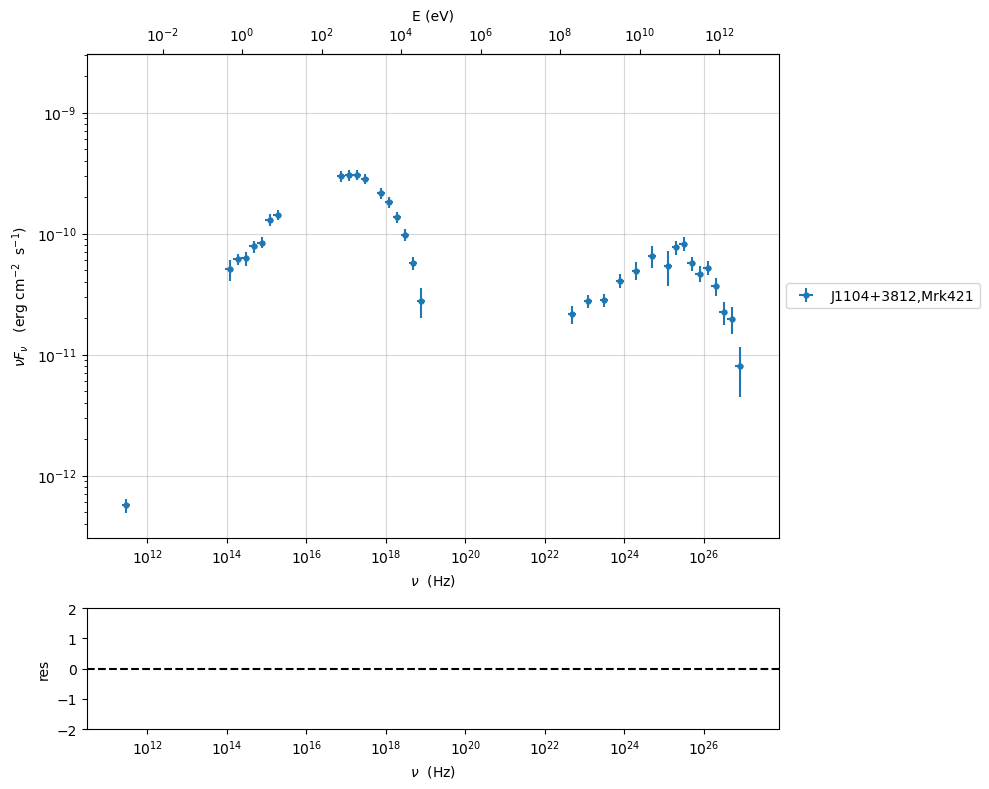

In [5]:
%matplotlib inline
sed_data=ObsData(data_table=data)
sed_data.group_data(bin_width=0.2)

sed_data.add_systematics(0.1,[10.**6,10.**29])
p=sed_data.plot_sed()
#p.setlim(y_min=1E-15,x_min=1E7,x_max=1E29)

In [6]:
sed_data.save('Mrk_401.pkl')

## phenomenological model constraining

### spectral indices


*** evaluating spectral indices for data ***



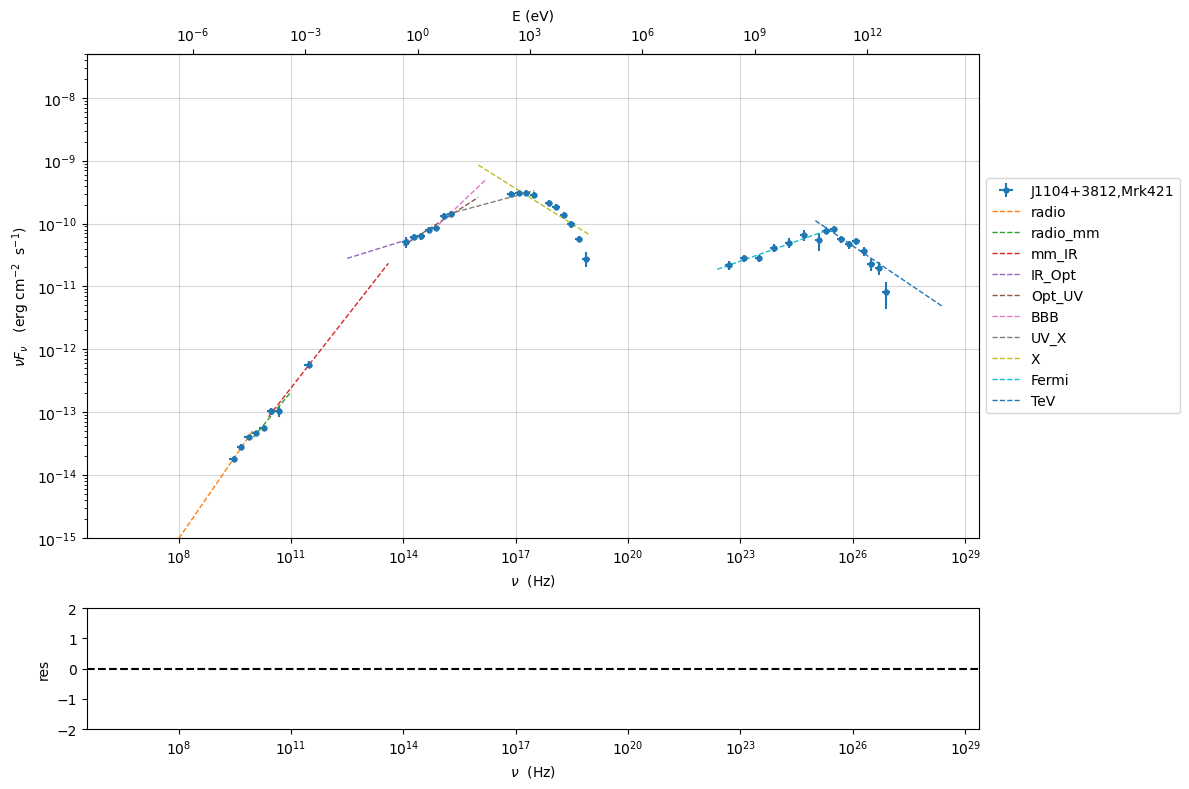

In [7]:
from jetset.sed_shaper import  SEDShape
my_shape=SEDShape(sed_data)
my_shape.eval_indices(minimizer='lsb',silent=True)
p=my_shape.plot_indices()
p.setlim(y_min=1E-15,y_max=5E-8)

### sed shaper

In [8]:
mm,best_fit=my_shape.sync_fit(check_host_gal_template=False,
                  Ep_start=None,
                  minimizer='lsb',
                  silent=True,
                  fit_range=[10.,21.])


*** Log-Polynomial fitting of the synchrotron component ***
---> first blind fit run,  fit range: [10.0, 21.0]
---> class:  HSP





model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
LogCubic,b,-1.563747e-01,-1.563747e-01,5.975434e-03,--,-1.000000e+00,-1.000000e+01,0.000000e+00,False
LogCubic,c,-1.052802e-02,-1.052802e-02,8.781942e-04,--,-1.000000e+00,-1.000000e+01,1.000000e+01,False
LogCubic,Ep,1.675324e+01,1.675324e+01,2.396636e-02,--,1.670206e+01,0.000000e+00,3.000000e+01,False
LogCubic,Sp,-9.494365e+00,-9.494365e+00,1.704982e-02,--,-1.000000e+01,-3.000000e+01,0.000000e+00,False


---> sync       nu_p=+1.675324e+01 (err=+2.396636e-02)  nuFnu_p=-9.494365e+00 (err=+1.704982e-02) curv.=-1.563747e-01 (err=+5.975434e-03)




*** Log-Polynomial fitting of the IC component ***
---> fit range: [23.0, 29.0]
---> LogCubic fit




model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
LogCubic,b,-2.274590e-01,-2.274590e-01,3.262166e-02,--,-1.000000e+00,-1.000000e+01,0.000000e+00,False
LogCubic,c,-6.259967e-02,-6.259967e-02,1.629408e-02,--,-1.000000e+00,-1.000000e+01,1.000000e+01,False
LogCubic,Ep,2.527207e+01,2.527207e+01,8.149547e-02,--,2.528644e+01,0.000000e+00,3.000000e+01,False
LogCubic,Sp,-1.014119e+01,-1.014119e+01,2.734754e-02,--,-1.000000e+01,-3.000000e+01,0.000000e+00,False


---> IC         nu_p=+2.527207e+01 (err=+8.149547e-02)  nuFnu_p=-1.014119e+01 (err=+2.734754e-02) curv.=-2.274590e-01 (err=+3.262166e-02)



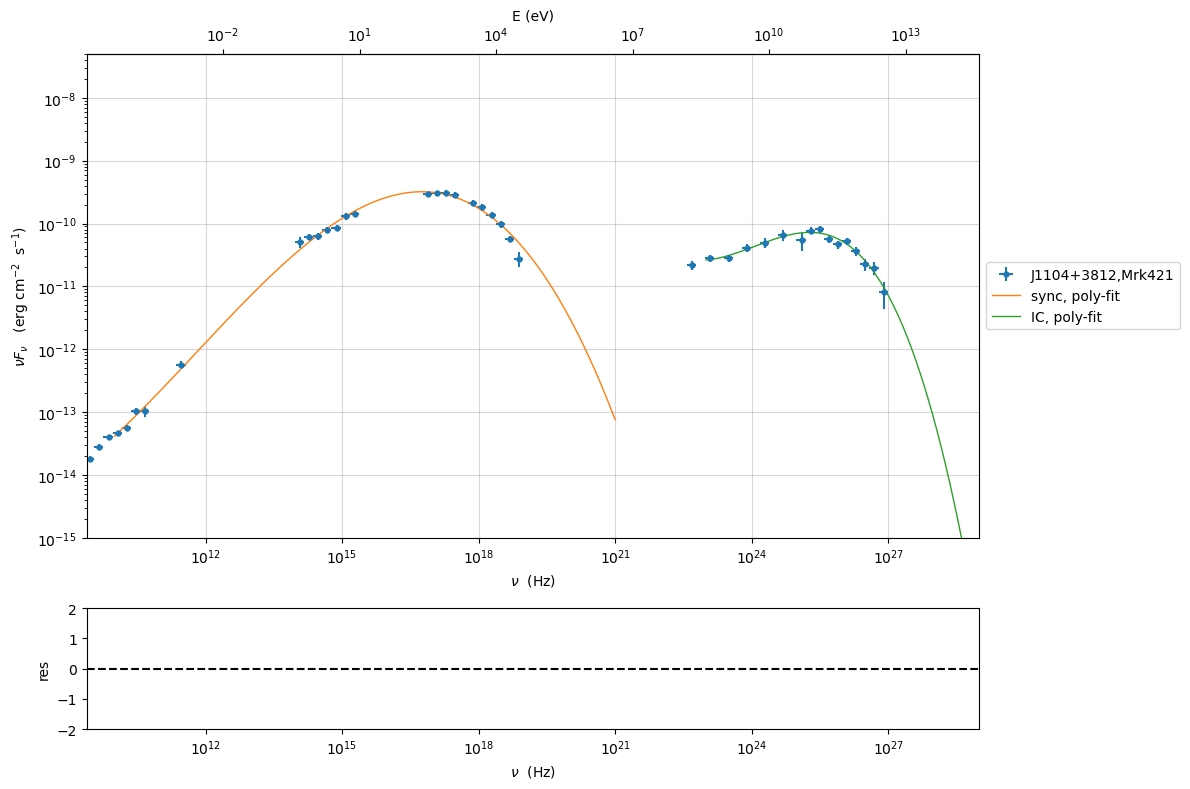

In [9]:
my_shape.IC_fit(fit_range=[23.,29.],minimizer='minuit',silent=True)
p=my_shape.plot_shape_fit()
p.setlim(y_min=1E-15,y_max=5E-8)

### Model constraining

In this step we are not fitting the model, we are just obtaining the phenomenological `pre_fit` model, that will be fitted in using minuit ore least-square bound, as shown below

In [10]:
from jetset.obs_constrain import ObsConstrain


sed_obspar=ObsConstrain(beaming=25,
                        B_range=[0.001,0.1],
                        t_var_sec=3*86400,
                        nu_cut_IR=1E12,
                        distr_e='bkn',
                        SEDShape=my_shape)


prefit_jet=sed_obspar.constrain_SSC_model(electron_distribution_log_values=False,silent=True)
prefit_jet.save_model('prefit_jet.pkl')


***  constrains parameters from observable ***



model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,2.219270e+16,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,6.618390e-02,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,2.500000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,3.080000e-02,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,4.103365e+02,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.136207e+06,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,1.238758e+00,0.000000e+00,--,False,False
jet_leptonic,gamma_break,turn-over-energy,lorentz-factor*,9.766963e+04,1.000000e+00,1.000000e+09,False,False


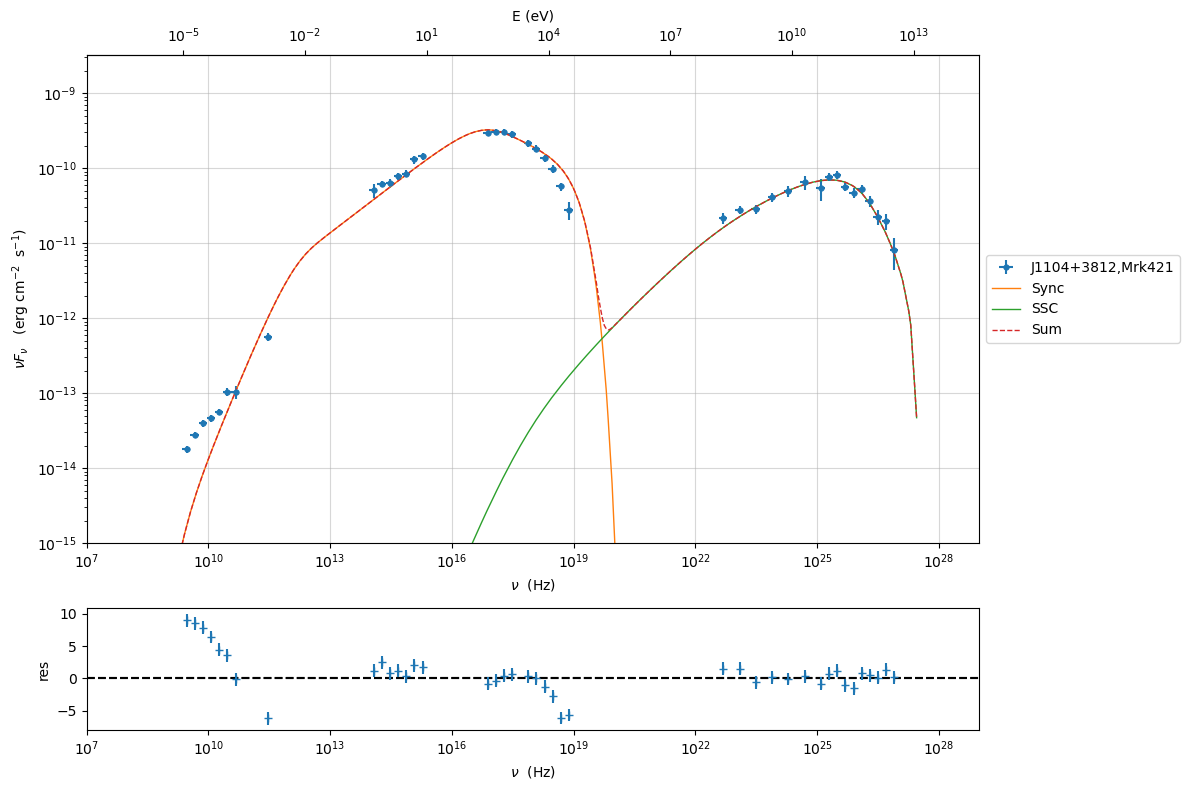

In [11]:
prefit_jet.eval()
pl=prefit_jet.plot_model(sed_data=sed_data)
pl.add_residual_plot(prefit_jet,sed_data)
pl.setlim(y_min=1E-15,x_min=1E7,x_max=1E29)

## Enabling the leptonic equilibrium

We build a jet with the leptonic equilibrium, and we copy the relevant parameters from the `prefit_jet` model

In [12]:
from jetset.jet_emitters_factory import InjEmittersFactory
from jetset.jet_model import Jet

q_inj = InjEmittersFactory().create_inj_emitters('pl')

lept_eq_jet=Jet(emitters_distribution=q_inj,name='leptonic_eq')
lept_eq_jet.parameters.p.val=prefit_jet.parameters.p.val
lept_eq_jet.parameters.z_cosm.val=prefit_jet.parameters.z_cosm.val
lept_eq_jet.parameters.R.val=prefit_jet.parameters.R.val
lept_eq_jet.parameters.B.val=prefit_jet.parameters.B.val
lept_eq_jet.parameters.gmin.val=prefit_jet.parameters.gmin.val
lept_eq_jet.parameters.gmax.val=prefit_jet.parameters.gmax.val

lept_eq_jet.parameters.beam_obj.val=prefit_jet.parameters.beam_obj.val


for the emitters density we use the standard tool

In [13]:
lept_eq_jet.set_N_from_nuFnu(nu_obs=1E15,nuFnu_obs=1E-10)

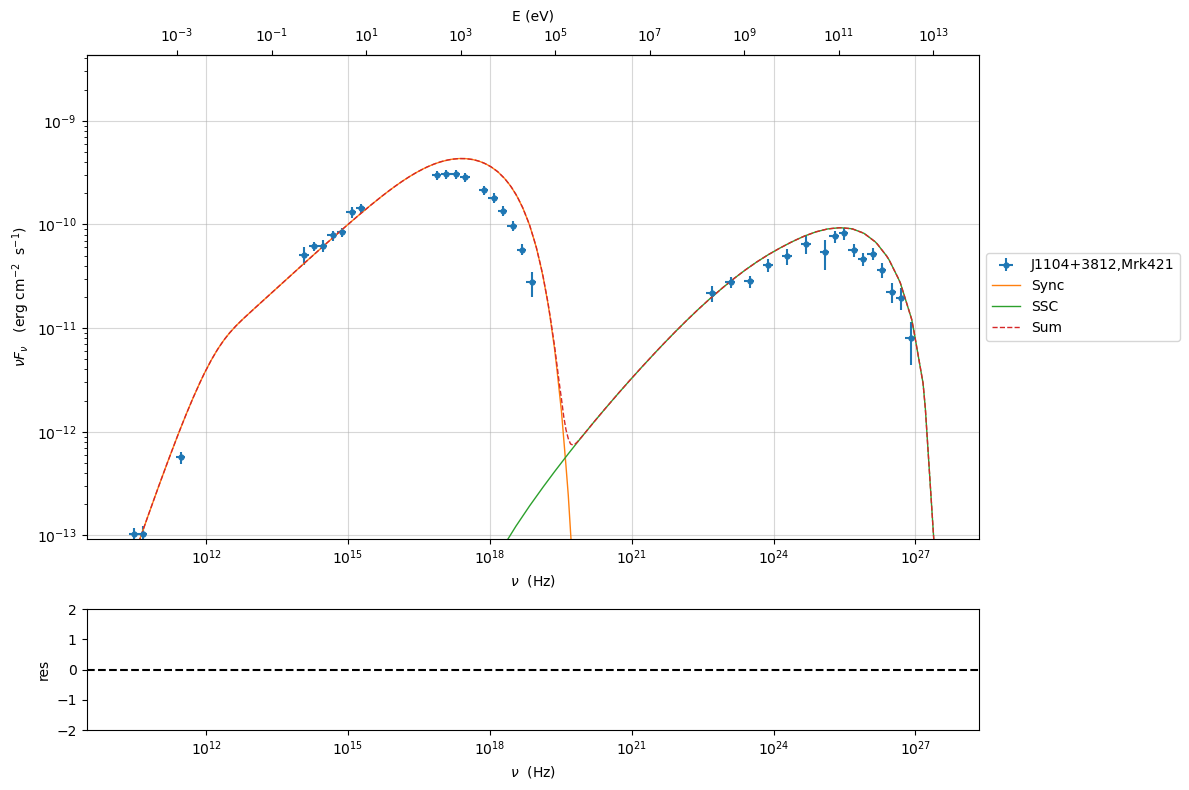

In [14]:
lept_eq_jet.eval()
lept_eq_jet.plot_model(sed_data=sed_data)

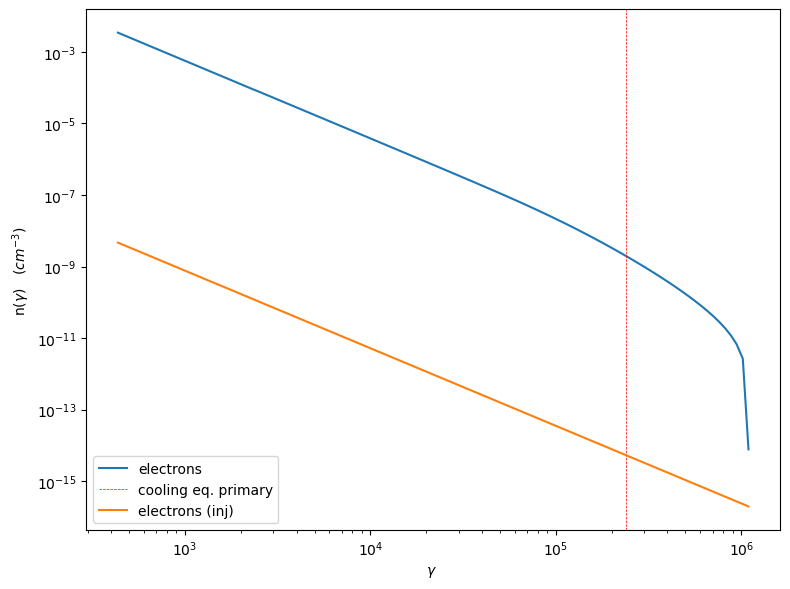

In [15]:
lept_eq_jet.emitters_distribution.plot()

In [16]:
lept_eq_jet.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
leptonic_eq,R,region_size,cm,2.219270e+16,1.000000e+03,1.000000e+30,False,False
leptonic_eq,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
leptonic_eq,B,magnetic_field,gauss,6.618390e-02,0.000000e+00,--,False,False
leptonic_eq,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
leptonic_eq,beam_obj,beaming,,2.500000e+01,1.000000e-04,--,False,False
leptonic_eq,z_cosm,redshift,,3.080000e-02,0.000000e+00,--,False,False
leptonic_eq,gmin,low-energy-cut-off,lorentz-factor*,4.103365e+02,1.000000e+00,1.000000e+09,False,False
leptonic_eq,gmax,high-energy-cut-off,lorentz-factor*,1.136207e+06,1.000000e+00,1.000000e+15,False,False
leptonic_eq,p,LE_spectral_slope,,2.169388e+00,-1.000000e+01,1.000000e+01,False,False
leptonic_eq,T_esc_e_primaries,escape_time,R / c,1.000000e+00,1.000000e+00,--,False,False


None

## Model fitting procedure

### Model fitting with LSB

In [17]:
from jetset.minimizer import ModelMinimizer

from jetset.model_manager import  FitModel


We use the `lept_eq_jet` model to build the `FitModel`

In [18]:
fit_model=FitModel( jet=lept_eq_jet, name='SSC-best-fit',template=None) 

In [19]:
fit_model.show_model_components()


--------------------------------------------------------------------------------
Composite model description
--------------------------------------------------------------------------------
name: SSC-best-fit  
type: composite_model  
components models:
 -model name: leptonic_eq model type: jet

--------------------------------------------------------------------------------


There is only one component, whit name `leptonic_eq`, that refers to the `lept_eq_jet` model component

We now set the gamma grid size to 200, ad we set `composite_expr`, anyhow, since we have only one component this step could be skipped

In [20]:
fit_model.leptonic_eq.set_gamma_grid_size(200)
fit_model.composite_expr='leptonic_eq'

#### Freezeing parameters and setting fit_range intervals

In [21]:

fit_model.freeze('leptonic_eq','z_cosm')
fit_model.freeze('leptonic_eq','R_H')
fit_model.freeze('leptonic_eq','T_esc_e_primaries')

fit_model.leptonic_eq.parameters.R.fit_range=[10**15.5,10**17.5]
fit_model.leptonic_eq.parameters.beam_obj.fit_range=[5., 50.]
fit_model.leptonic_eq.parameters.gmax.fit_range=[1E5, 5E6]
fit_model.leptonic_eq.parameters.gmin.fit_range=[10, 1000]
fit_model.leptonic_eq.parameters.T_esc_e_primaries.val=1
fit_model.leptonic_eq.parameters.L_inj.fit_range=[1E38, 1E43]



In [22]:
fit_model.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
leptonic_eq,R,region_size,cm,2.219270e+16,1.000000e+03,1.000000e+30,False,False
leptonic_eq,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
leptonic_eq,B,magnetic_field,gauss,6.618390e-02,0.000000e+00,--,False,False
leptonic_eq,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
leptonic_eq,beam_obj,beaming,,2.500000e+01,1.000000e-04,--,False,False
leptonic_eq,z_cosm,redshift,,3.080000e-02,0.000000e+00,--,False,True
leptonic_eq,gmin,low-energy-cut-off,lorentz-factor*,4.103365e+02,1.000000e+00,1.000000e+09,False,False
leptonic_eq,gmax,high-energy-cut-off,lorentz-factor*,1.136207e+06,1.000000e+00,1.000000e+15,False,False
leptonic_eq,p,LE_spectral_slope,,2.169388e+00,-1.000000e+01,1.000000e+01,False,False
leptonic_eq,T_esc_e_primaries,escape_time,R / c,1.000000e+00,1.000000e+00,--,False,True


None

#### Building the ModelMinimizer object

In [23]:
model_minimizer_minuit=ModelMinimizer('minuit')
best_fit_minuit=model_minimizer_minuit.fit(fit_model,
                                           sed_data,
                                           1E11,
                                           1E29,
                                           fitname='SSC-best-fit-minuit',
                                           max_ev=10000,
                                           repeat=1)

filtering data in fit range = [1.000000e+11,1.000000e+29]
data length 34

*** start fit process ***
----- 


0it [00:00, ?it/s]

- best chisq=4.72145e+01

-------------------------------------------------------------------------
Fit report

Model: SSC-best-fit-minuit


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
leptonic_eq,R,region_size,cm,3.176680e+16,1.000000e+03,1.000000e+30,False,False
leptonic_eq,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
leptonic_eq,B,magnetic_field,gauss,9.382692e-02,0.000000e+00,--,False,False
leptonic_eq,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
leptonic_eq,beam_obj,beaming,,1.692360e+01,1.000000e-04,--,False,False
leptonic_eq,z_cosm,redshift,,3.080000e-02,0.000000e+00,--,False,True
leptonic_eq,gmin,low-energy-cut-off,lorentz-factor*,4.018938e+02,1.000000e+00,1.000000e+09,False,False
leptonic_eq,gmax,high-energy-cut-off,lorentz-factor*,9.198642e+05,1.000000e+00,1.000000e+15,False,False
leptonic_eq,p,LE_spectral_slope,,2.014570e+00,-1.000000e+01,1.000000e+01,False,False
leptonic_eq,T_esc_e_primaries,escape_time,R / c,1.000000e+00,1.000000e+00,--,False,True



converged=True
calls=2787
mesg=


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 47.21                      │             Nfcn = 2787              │
│ EDM = 1.71e+04 (Goal: 0.0002)    │           time = 17.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │        Covariance APPROXIMATE        │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ par_0 │31.7668e15 │ 0.0013e15 │            │            │3.16228e+15│3.16228e+17│       │
│ 1 │ par_1 │  0.0938   │  0.0020   │            │            │    0    │         │       │
│ 2 │ par_2 │   16.92   │   0.10    │            │            │    5    │   50    │       │
│ 3 │ par_3 │    402    │     6     │            │            │   10    │  1000   │       │
│ 4 │ par_4 │  0.920e6  │  0.022e6  │            │            │ 100000  │  5e+06  │       │
│ 5 │ par_5 │   2.015   │   0.010   │            │            │   -10   │   10    │       │
│ 6 │ par_6 │  224e39   │   4e39    │            │            │  1e+38  │  1e+43  │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘

dof=27
chisq=47.214549, chisq/red=1.748687 null hypothesis sig=0.009383

best fit pars


model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
leptonic_eq,R,3.176680e+16,3.176680e+16,1.265185e+12,--,2.219270e+16,3.162278e+15,3.162278e+17,False
leptonic_eq,R_H,1.000000e+17,--,--,--,1.000000e+17,0.000000e+00,--,True
leptonic_eq,B,9.382692e-02,9.382692e-02,2.033169e-03,--,6.618390e-02,0.000000e+00,--,False
leptonic_eq,NH_cold_to_rel_e,1.000000e+00,--,--,--,1.000000e+00,0.000000e+00,--,True
leptonic_eq,beam_obj,1.692360e+01,1.692360e+01,9.829265e-02,--,2.500000e+01,5.000000e+00,5.000000e+01,False
leptonic_eq,z_cosm,3.080000e-02,--,--,--,3.080000e-02,0.000000e+00,--,True
leptonic_eq,gmin,4.018938e+02,4.018938e+02,5.731598e+00,--,4.103365e+02,1.000000e+01,1.000000e+03,False
leptonic_eq,gmax,9.198642e+05,9.198642e+05,2.187745e+04,--,1.136207e+06,1.000000e+05,5.000000e+06,False
leptonic_eq,p,2.014570e+00,2.014570e+00,1.009831e-02,--,2.169388e+00,-1.000000e+01,1.000000e+01,False
leptonic_eq,T_esc_e_primaries,1.000000e+00,--,--,--,1.000000e+00,1.000000e+00,--,True


-------------------------------------------------------------------------




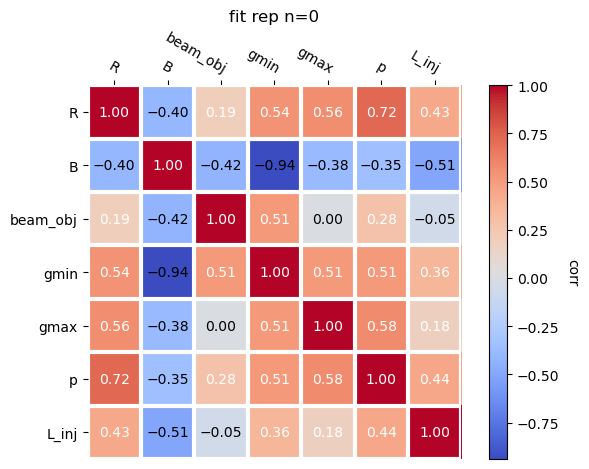

In [24]:
p=model_minimizer_minuit.plot_corr_matrix()

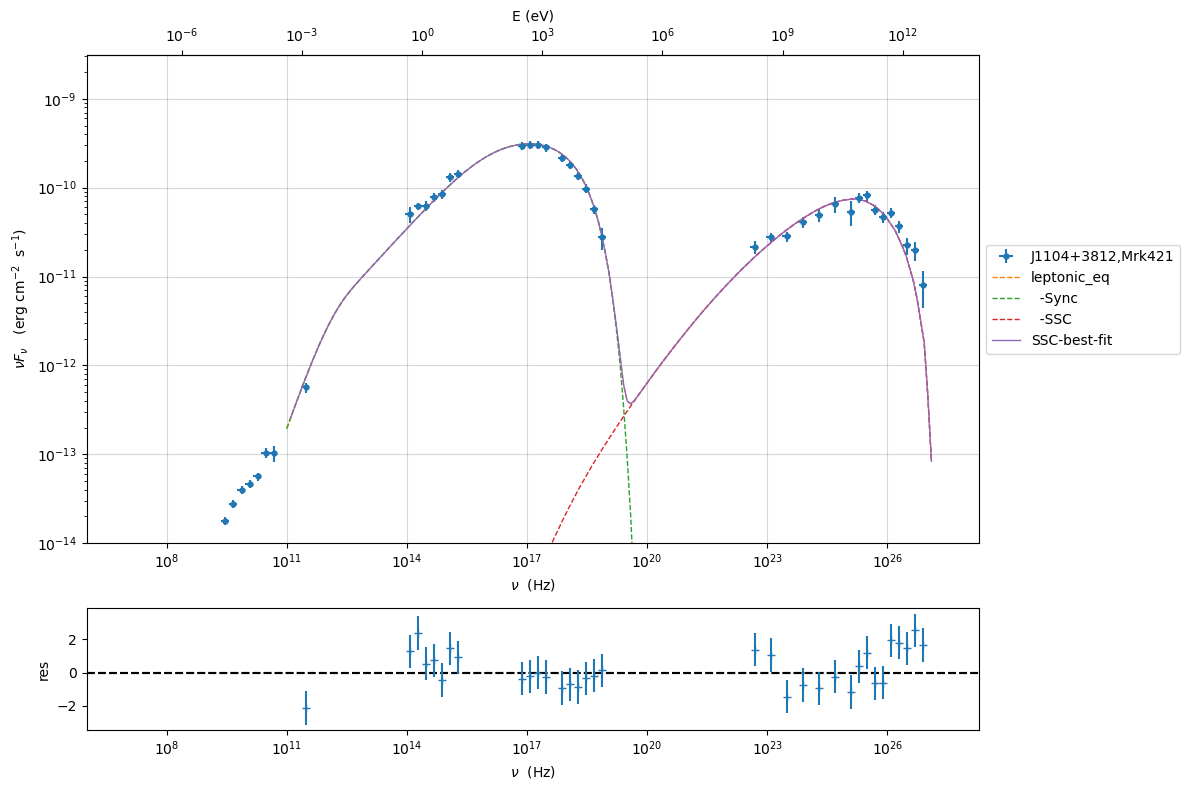

In [25]:
%matplotlib inline
fit_model.eval()
p2=fit_model.plot_model(sed_data=sed_data)
p2.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

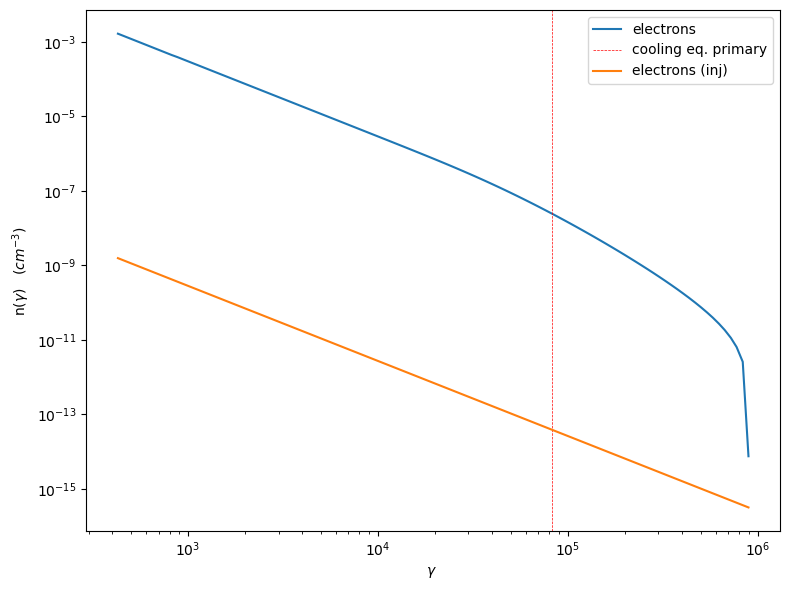

In [26]:
fit_model.leptonic_eq.emitters_distribution.plot()


#### saving fit model, model minimizer

In [27]:
best_fit_minuit.save_report('SSC-best-fit-minuit.pkl')
model_minimizer_minuit.save_model('model_minimizer_minuit.pkl')
fit_model.save_model('fit_model_minuit.pkl')

## MCMC sampling

### creating and setting the sampler

In [28]:
from jetset.data_loader import ObsData

sed_data=ObsData.load('Mrk_401.pkl')

In [29]:
from jetset.mcmc import McmcSampler
from jetset.minimizer import ModelMinimizer


In [30]:
model_minimizer = ModelMinimizer.load_model('model_minimizer_minuit.pkl')

mcmc=McmcSampler(model_minimizer)


You can inspect the mcmc parameters using:

In [31]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str11,str17,float64,bool,float64,float64,float64,float64,float64,float64,bool
leptonic_eq,gmin,4.018938e+02,False,4.018938e+02,--,--,--,1.000000e+01,1.000000e+03,False
leptonic_eq,gmax,9.198642e+05,False,9.198642e+05,--,--,--,1.000000e+05,5.000000e+06,False
leptonic_eq,p,2.014570e+00,False,2.014570e+00,--,--,--,-1.000000e+01,1.000000e+01,False
leptonic_eq,L_inj,2.239052e+41,False,2.239052e+41,--,--,--,1.000000e+38,1.000000e+43,False
leptonic_eq,R,3.176680e+16,False,3.176680e+16,--,--,--,3.162278e+15,3.162278e+17,False
leptonic_eq,B,9.382692e-02,False,9.382692e-02,--,--,--,0.000000e+00,--,False
leptonic_eq,beam_obj,1.692360e+01,False,1.692360e+01,--,--,--,5.000000e+00,5.000000e+01,False
leptonic_eq,T_esc_e_primaries,1.000000e+00,False,--,--,--,--,1.000000e+00,--,True
leptonic_eq,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


If you want to exclude or include parameters from the samplers just freeze/free them 

In [32]:
mcmc.model.leptonic_eq.parameters.T_esc_e_primaries.frozen=True


You can set different bounds for all the free parameters with the instruction below. In case you want to preserve the `fit_range` defined in the frequentist minimizer you can pass `preserve_fit_range=True`

In [33]:
mcmc.set_bounds(bound=5.0,bound_rel=True)

par: gmin  ref value:  401.8937970173682  mcmc bounds: [10, 1000]
par: gmax  ref value:  919864.2340355621  mcmc bounds: [100000.0, 5000000.0]
par: p  ref value:  2.0145703169604  mcmc bounds: [np.float64(-8.0582812678416), 10]
par: L_inj  ref value:  2.2390519563880357e+41  mcmc bounds: [1e+38, np.float64(1.3434311738328214e+42)]
par: R  ref value:  3.1766796255270484e+16  mcmc bounds: [3162277660168379.5, np.float64(1.906007775316229e+17)]
par: B  ref value:  0.09382691639943719  mcmc bounds: [0, np.float64(0.5629614983966231)]
par: beam_obj  ref value:  16.92360354802938  mcmc bounds: [5.0, 50.0]


Or, you can set per-parameter bounds as follows, passing the actual bound for each parameter.

In [34]:
mcmc.set_bounds(comp_name='leptonic_eq',par_name='L_inj',par_bounds=[1E37,1E43])
mcmc.set_bounds(comp_name='leptonic_eq',par_name='gmin',par_bounds=[10,2000])



par: L_inj  ref value:  2.2390519563880357e+41  mcmc bounds: [1e+38, 1e+43]
par: gmin  ref value:  401.8937970173682  mcmc bounds: [10, 1000]


In [35]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str11,str17,float64,bool,float64,float64,float64,float64,float64,float64,bool
leptonic_eq,gmin,4.018938e+02,False,4.018938e+02,--,--,--,1.000000e+01,1.000000e+03,False
leptonic_eq,gmax,9.198642e+05,False,9.198642e+05,--,--,--,1.000000e+05,5.000000e+06,False
leptonic_eq,p,2.014570e+00,False,2.014570e+00,--,--,--,-8.058281e+00,1.000000e+01,False
leptonic_eq,L_inj,2.239052e+41,False,2.239052e+41,--,--,--,1.000000e+38,1.000000e+43,False
leptonic_eq,R,3.176680e+16,False,3.176680e+16,--,--,--,3.162278e+15,1.906008e+17,False
leptonic_eq,B,9.382692e-02,False,9.382692e-02,--,--,--,0.000000e+00,5.629615e-01,False
leptonic_eq,beam_obj,1.692360e+01,False,1.692360e+01,--,--,--,5.000000e+00,5.000000e+01,False
leptonic_eq,T_esc_e_primaries,1.000000e+00,False,--,--,--,--,1.000000e+00,--,True
leptonic_eq,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


In [36]:
mcmc.run_sampler(nwalkers=30, burnin=50,steps=500,progress='notebook')


mcmc run starting



  0%|          | 0/500 [00:00<?, ?it/s]

mcmc run done, with 1 threads took 121.71 seconds
----------------------------
MCMC best fit solution
comp: leptonic_eq par: gmin  mcmc best fit val: 958.6689545672559 quantiles(0.16,0.5,0.84): [487.88899001 754.30210538 910.1646663 ] 
comp: leptonic_eq par: gmax  mcmc best fit val: 1214539.37077518 quantiles(0.16,0.5,0.84): [ 932696.07485653 1107649.3466804  1279351.19165406] 
comp: leptonic_eq par: p  mcmc best fit val: 2.243687864515942 quantiles(0.16,0.5,0.84): [2.03505938 2.13381072 2.20868741] 
comp: leptonic_eq par: L_inj  mcmc best fit val: 2.2785020829625934e+41 quantiles(0.16,0.5,0.84): [2.14821537e+41 2.43922542e+41 2.93184298e+41] 
comp: leptonic_eq par: R  mcmc best fit val: 4.733284879007039e+16 quantiles(0.16,0.5,0.84): [3.33714698e+16 4.02729862e+16 5.25323535e+16] 
comp: leptonic_eq par: B  mcmc best fit val: 0.04448230871191803 quantiles(0.16,0.5,0.84): [0.0491244  0.06054322 0.08548969] 
comp: leptonic_eq par: beam_obj  mcmc best fit val: 20.686521288961064 quantiles

Showing the MCMC parameters. Now MCMC bestfit values are updated to the best-fit MCMC solution


In [37]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str11,str17,float64,bool,float64,float64,float64,float64,float64,float64,bool
leptonic_eq,gmin,9.586690e+02,False,9.586690e+02,4.878890e+02,7.543021e+02,9.101647e+02,1.000000e+01,1.000000e+03,False
leptonic_eq,gmax,1.214539e+06,False,1.214539e+06,9.326961e+05,1.107649e+06,1.279351e+06,1.000000e+05,5.000000e+06,False
leptonic_eq,p,2.243688e+00,False,2.243688e+00,2.035059e+00,2.133811e+00,2.208687e+00,-8.058281e+00,1.000000e+01,False
leptonic_eq,L_inj,2.278502e+41,False,2.278502e+41,2.148215e+41,2.439225e+41,2.931843e+41,1.000000e+38,1.000000e+43,False
leptonic_eq,R,4.733285e+16,False,4.733285e+16,3.337147e+16,4.027299e+16,5.253235e+16,3.162278e+15,1.906008e+17,False
leptonic_eq,B,4.448231e-02,False,4.448231e-02,4.912440e-02,6.054322e-02,8.548969e-02,0.000000e+00,5.629615e-01,False
leptonic_eq,beam_obj,2.068652e+01,False,2.068652e+01,1.663712e+01,1.789799e+01,1.961053e+01,5.000000e+00,5.000000e+01,False
leptonic_eq,T_esc_e_primaries,1.000000e+00,False,--,--,--,--,1.000000e+00,--,True
leptonic_eq,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


### post-run tuning of the burnin
We plot the chains, before and after, tuning the burnin (using atuocorrelation time of emcee).

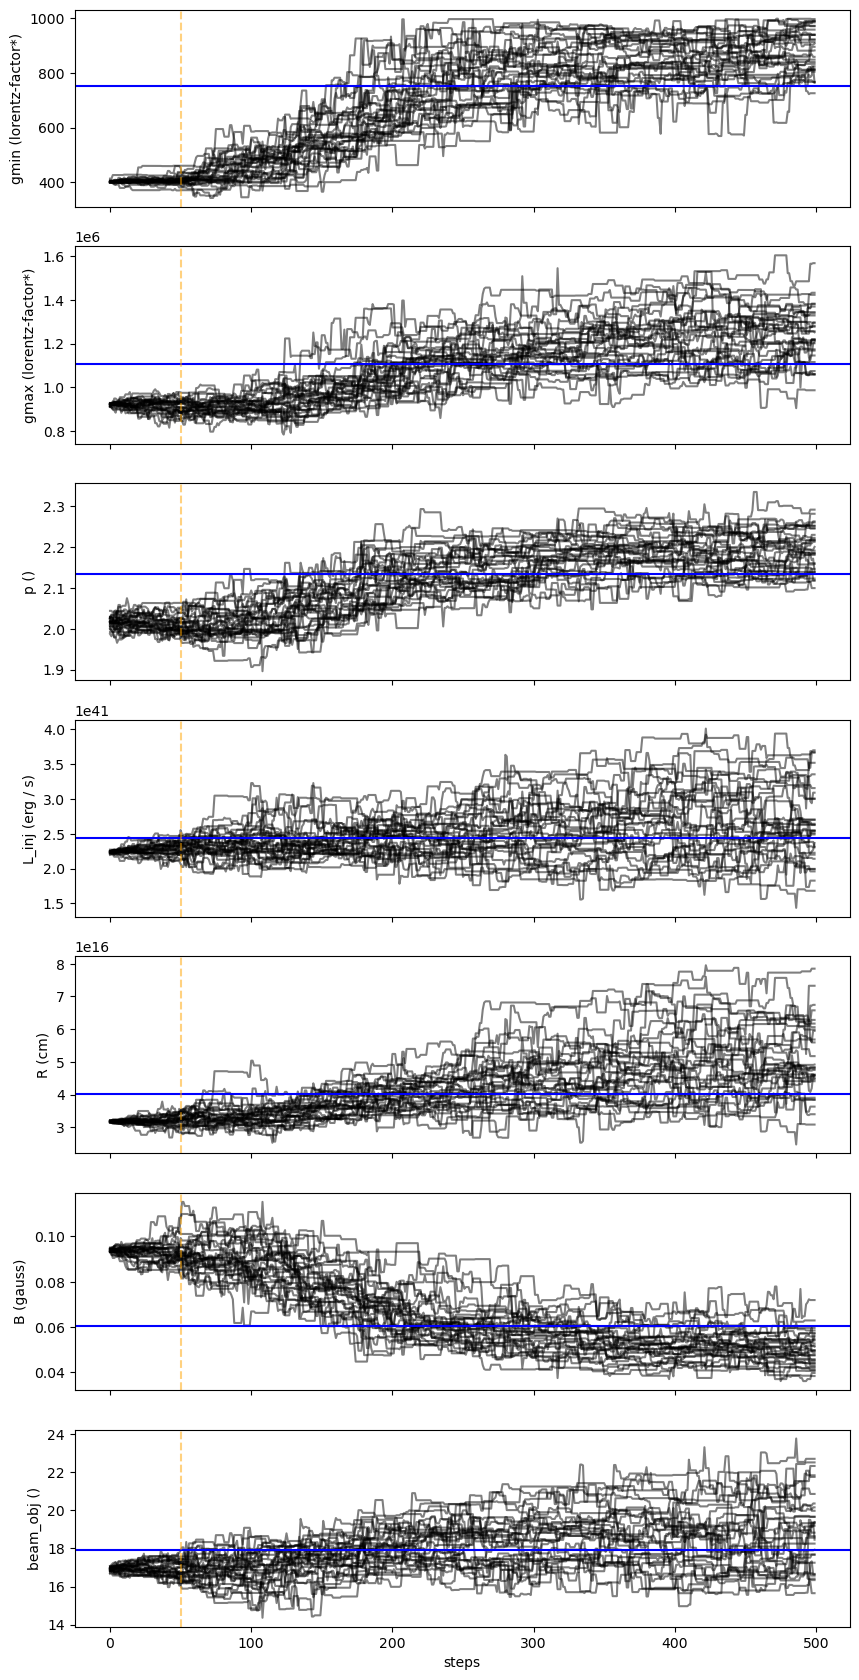

In [38]:
p=mcmc.plot_chain()

----------------------------
MCMC best fit solution
comp: leptonic_eq par: gmin  mcmc best fit val: 958.6689545672559 quantiles(0.16,0.5,0.84): [624.58493777 794.31592391 921.60319658] 
comp: leptonic_eq par: gmax  mcmc best fit val: 1214539.37077518 quantiles(0.16,0.5,0.84): [1010888.3804931  1144630.12833508 1301342.5544069 ] 
comp: leptonic_eq par: p  mcmc best fit val: 2.243687864515942 quantiles(0.16,0.5,0.84): [2.0909979  2.1593199  2.21568695] 
comp: leptonic_eq par: L_inj  mcmc best fit val: 2.2785020829625934e+41 quantiles(0.16,0.5,0.84): [2.14814858e+41 2.49146004e+41 3.00607947e+41] 
comp: leptonic_eq par: R  mcmc best fit val: 4.733284879007039e+16 quantiles(0.16,0.5,0.84): [3.57603158e+16 4.28010975e+16 5.44575520e+16] 
comp: leptonic_eq par: B  mcmc best fit val: 0.04448230871191803 quantiles(0.16,0.5,0.84): [0.04799269 0.05728796 0.07145664] 
comp: leptonic_eq par: beam_obj  mcmc best fit val: 20.686521288961064 quantiles(0.16,0.5,0.84): [16.87471857 18.2746194  19.89873

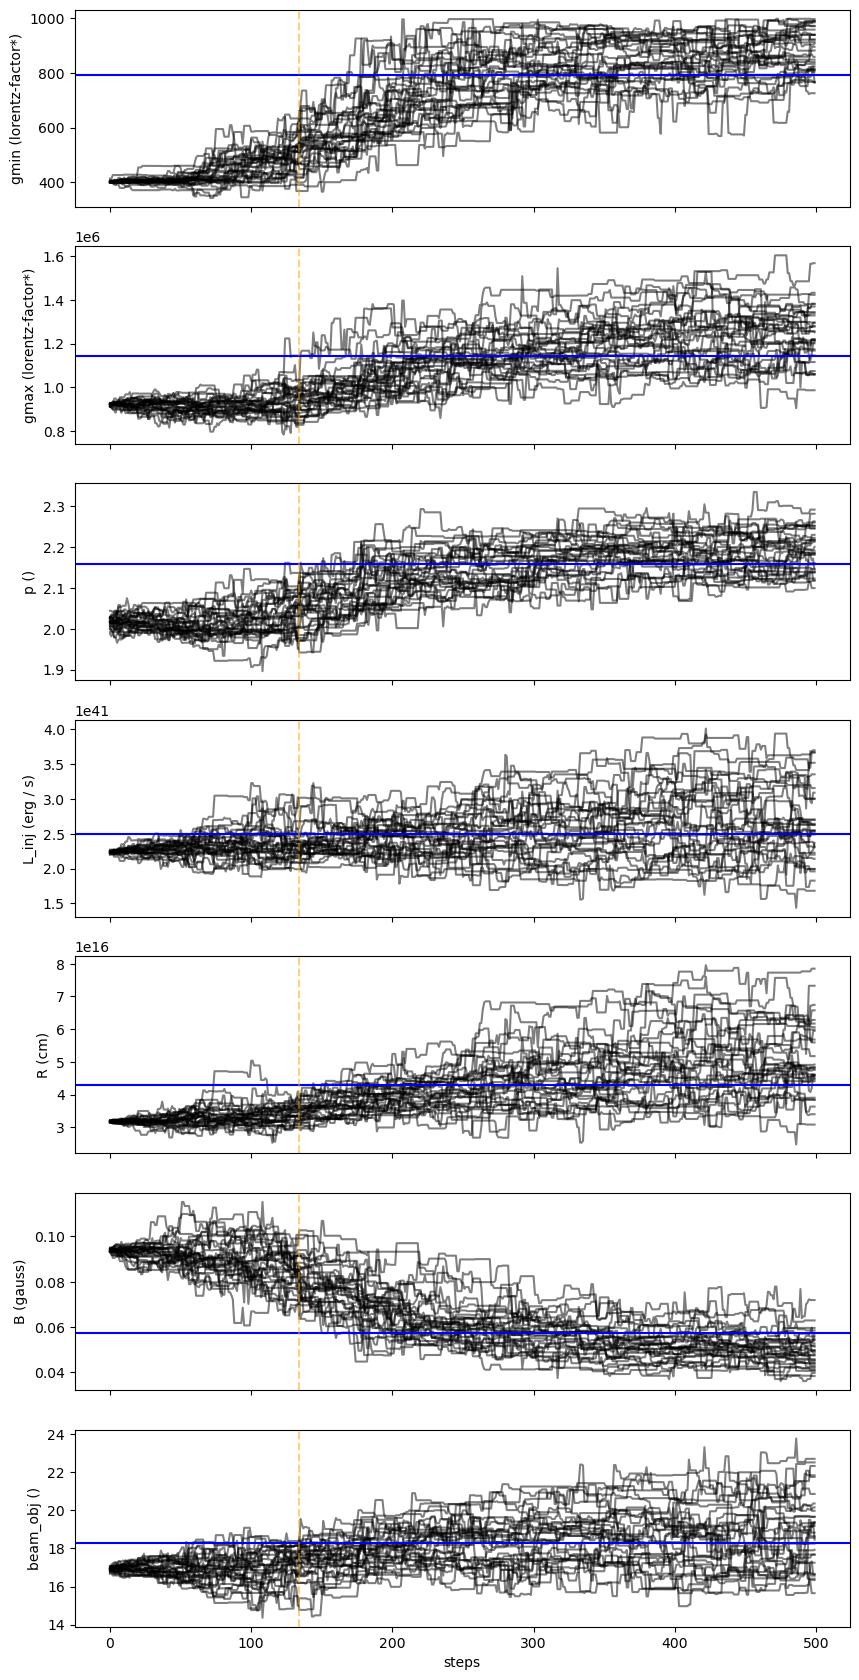

In [39]:
mcmc.tune_burnin(tau_coeff=2)
p=mcmc.plot_chain()

The updated burnin value has increased compared to the initial one, now the chain samples a parameter space closer to the convergence.

### plotting the posterior corner plot

To have a better rendering on the scatter plot, we redefine the plot labels

In [40]:
mcmc.set_plot_label('L_inj',r'$L_{inj}$',comp_name='leptonic_eq')
mcmc.set_plot_label('B',r'$B$',comp_name='leptonic_eq')
mcmc.set_plot_label('gmin',r'$\gamma_{\rm min}$',comp_name='leptonic_eq')
mcmc.set_plot_label('gmax',r'$\gamma_{\rm max}$',comp_name='leptonic_eq')
mcmc.set_plot_label('beam_obj',r'$\delta$',comp_name='leptonic_eq')
mcmc.set_plot_label('p',r'$p$',comp_name='leptonic_eq')


the code below lets you tuning the output

1) mpl.rcParams['figure.dpi'] if you increase it you get a better definition
2) title_fmt=".2E" this is the format for python, 2 significant digits, scientific notation
3) title_kwargs=dict(fontsize=12) you can change the fontsize

Per-component corner plot

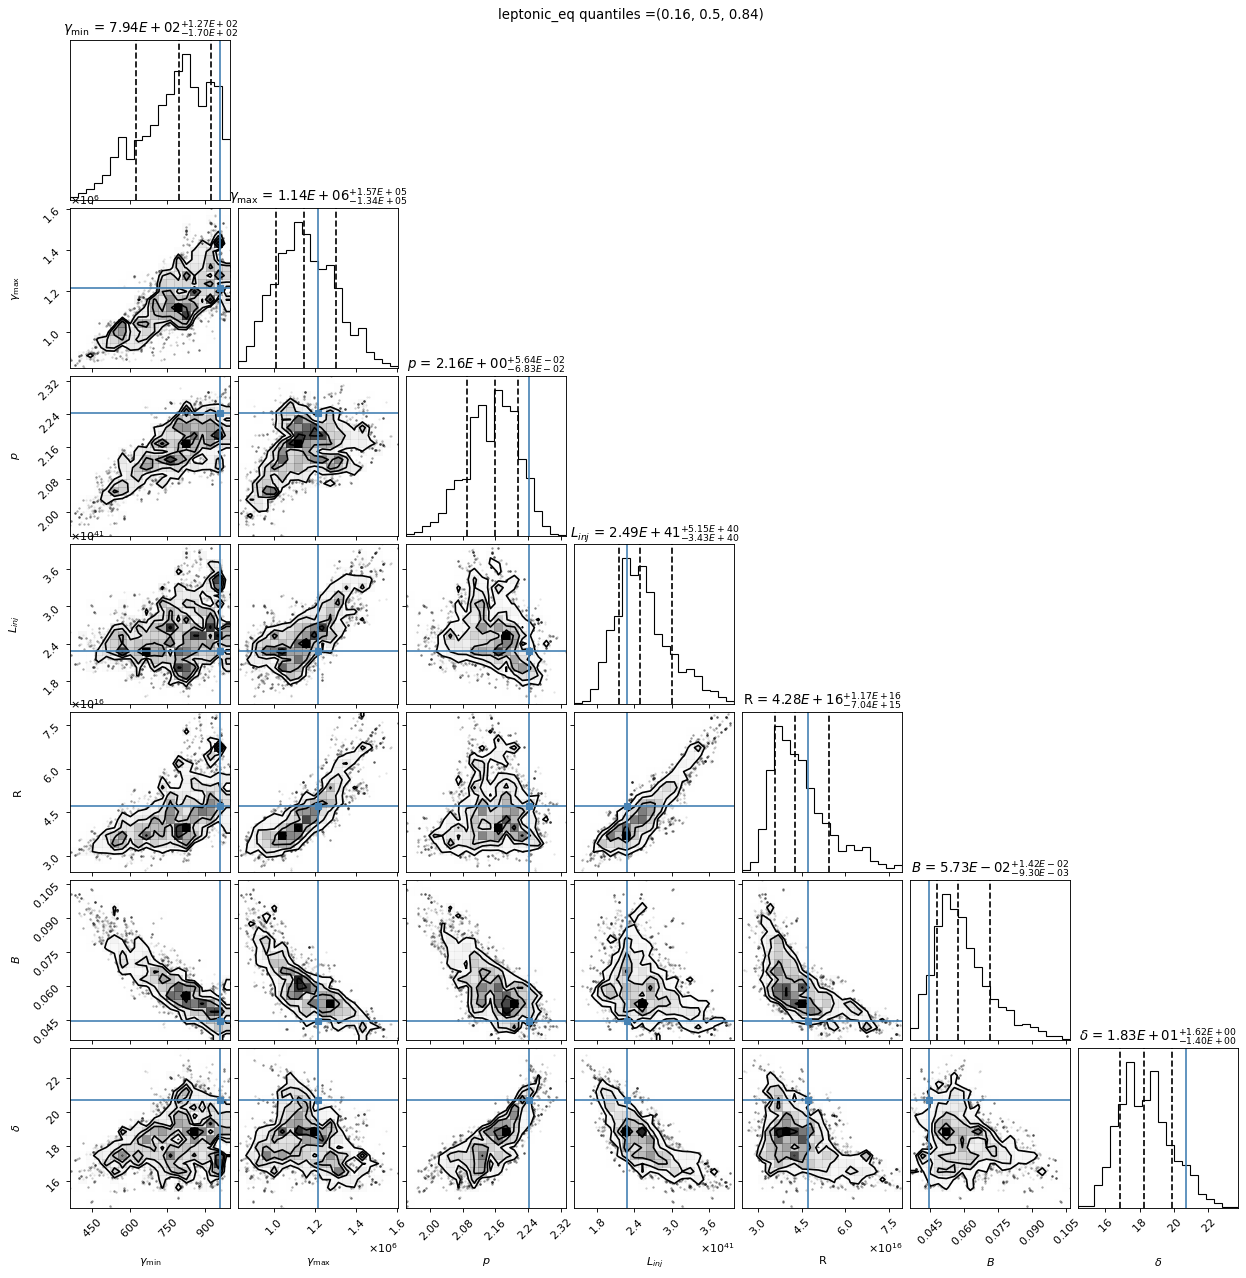

In [41]:
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 80
f=mcmc.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

In [42]:
print(mcmc.acceptance_fraction)

0.3033333333333333


### plotting the model

To plot the sampled model range against the input mcmc best-fit model

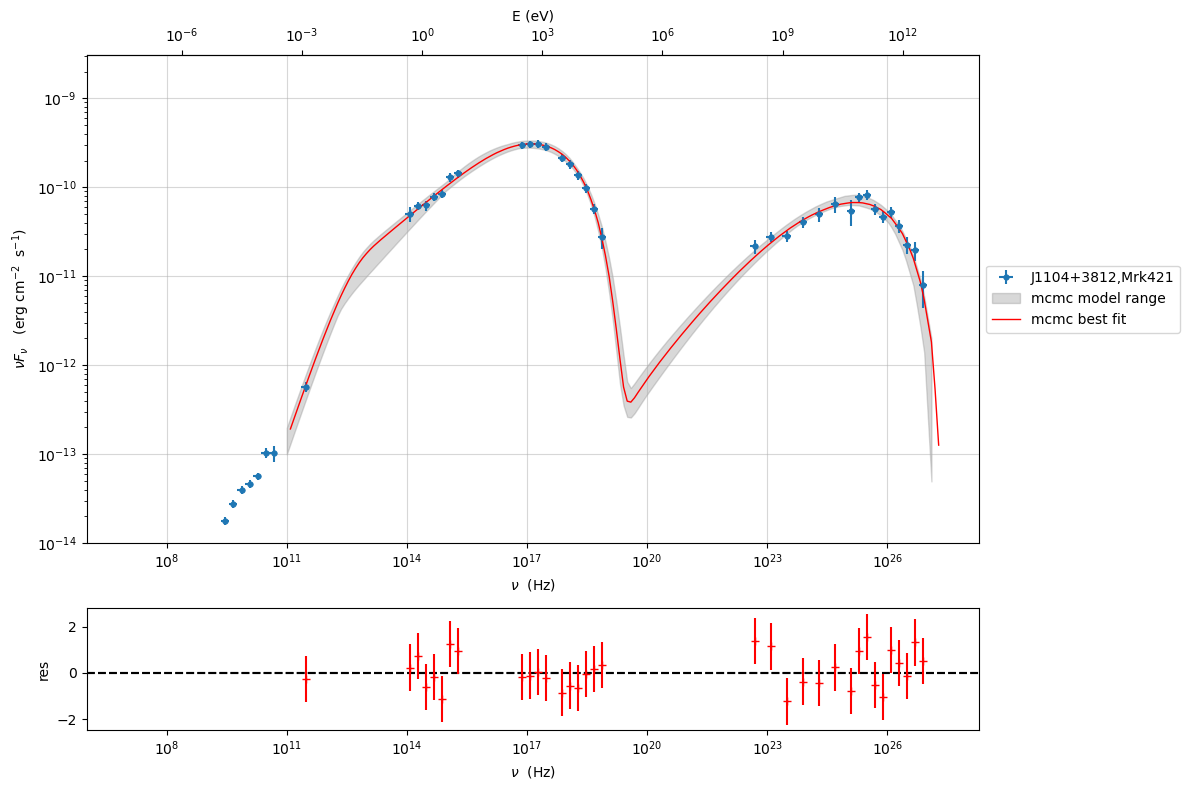

In [43]:

from jetset.data_loader import ObsData
sed_data=ObsData.load('Mrk_401.pkl')
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=100)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

To plot the mcmc best-fit model providing quantiles. The size parameter defines the number of samples to use to extract the quantiles. I am using a size equal to the number of steps

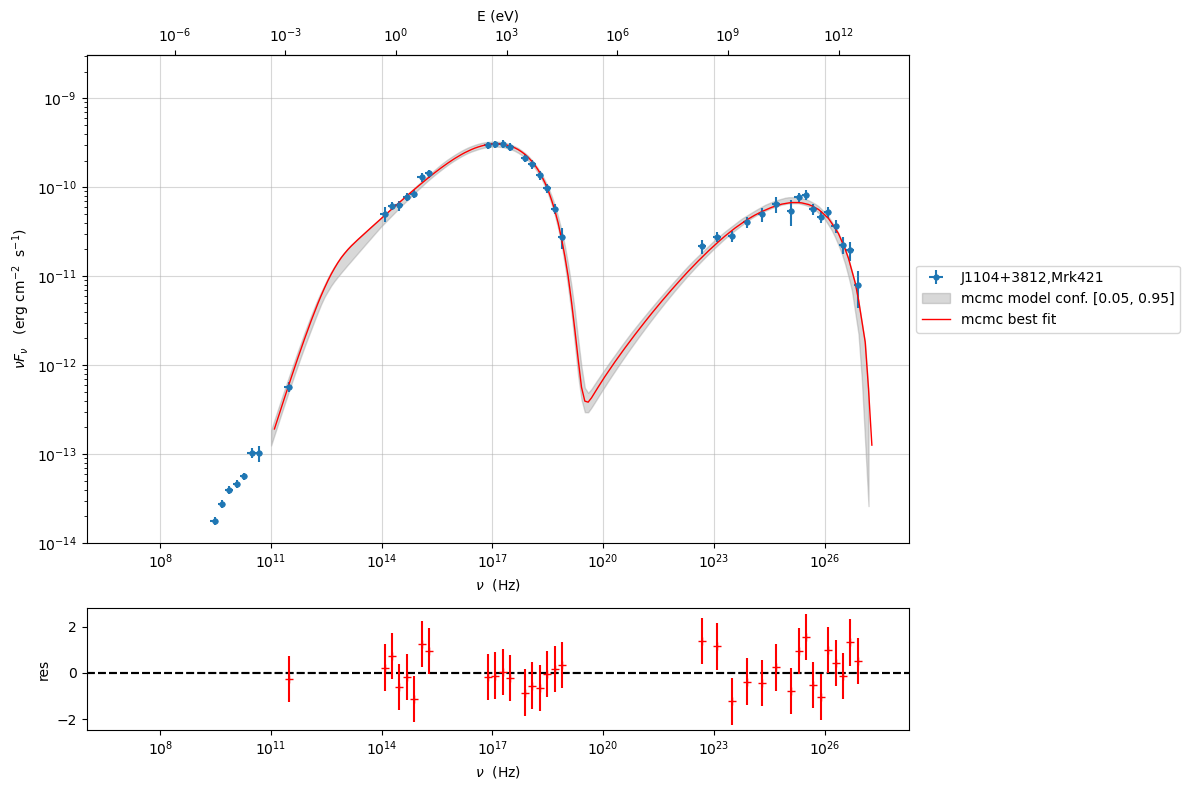

In [44]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95])
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

If you want to plot also the model components, pass the argument `plot_components=True`

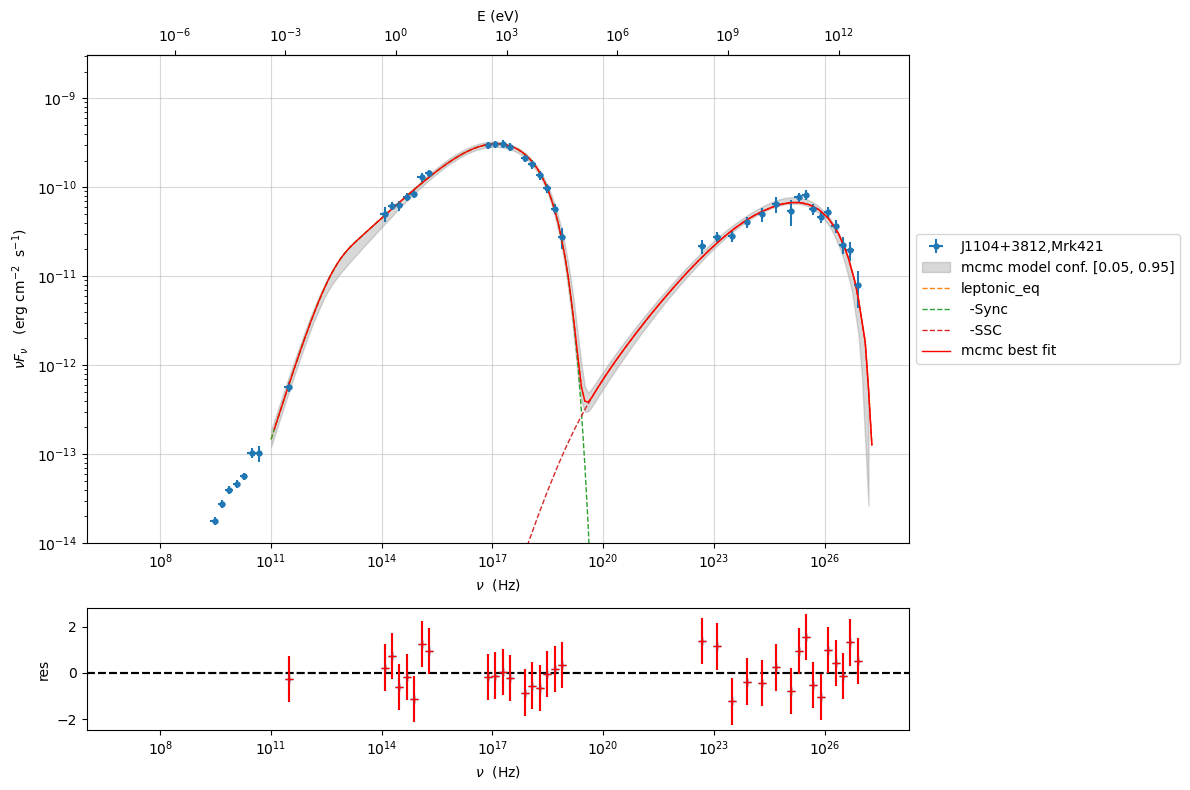

In [45]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=500,quantiles=[0.05,0.95],plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

To plot the frequentist  best-fit  model range,p roviding quantiles, provide (``plot_mcmc_best_fit_model=False``)

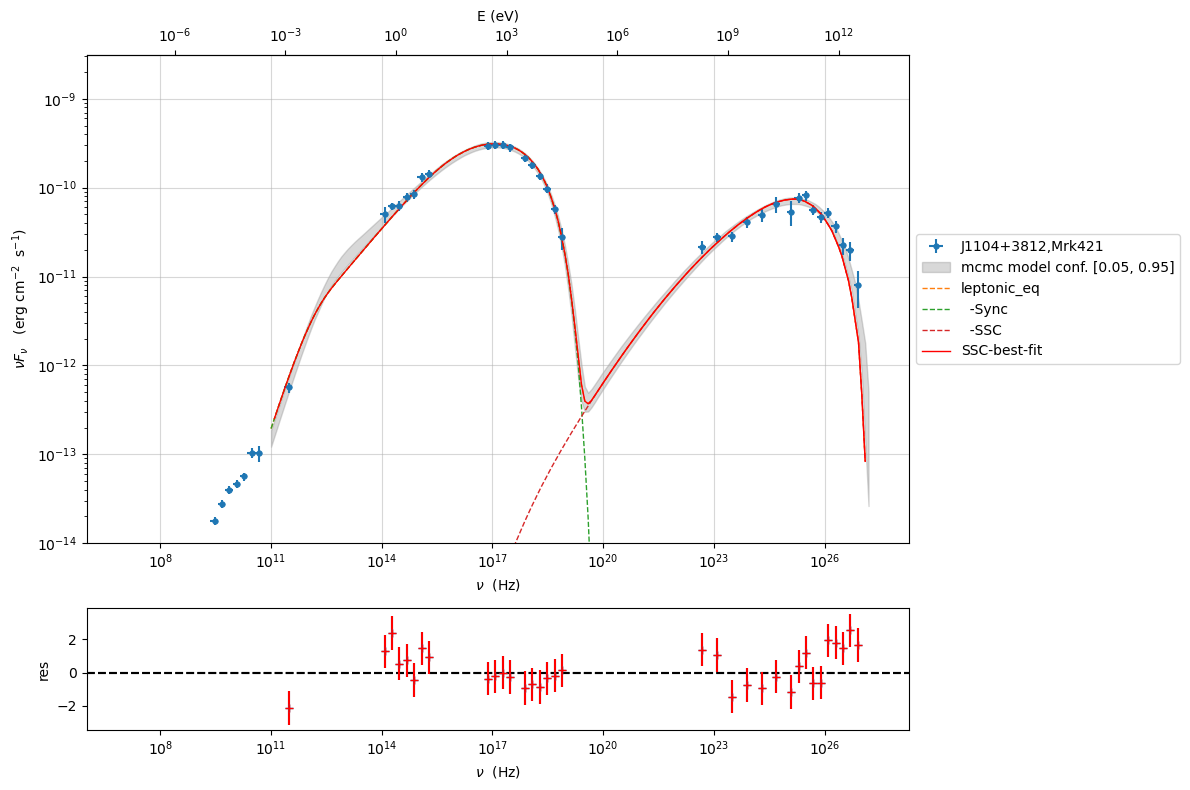

In [46]:
mpl.rcParams['figure.dpi'] = 100
p=mcmc.plot_model(sed_data=sed_data,size=500,quantiles=[0.05,0.95], plot_mcmc_best_fit_model=False,plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

### plotting chains and individual posteriors

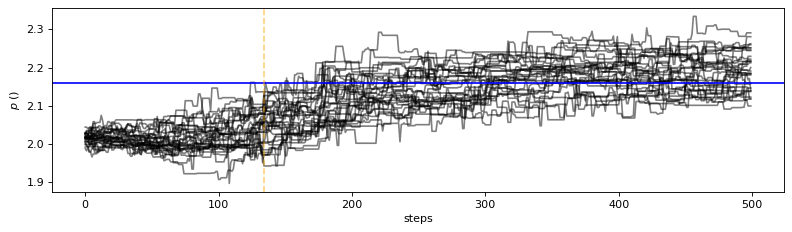

In [47]:
import matplotlib.pylab as plt

mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(par_name='p',log_plot=False)
plt.tight_layout()

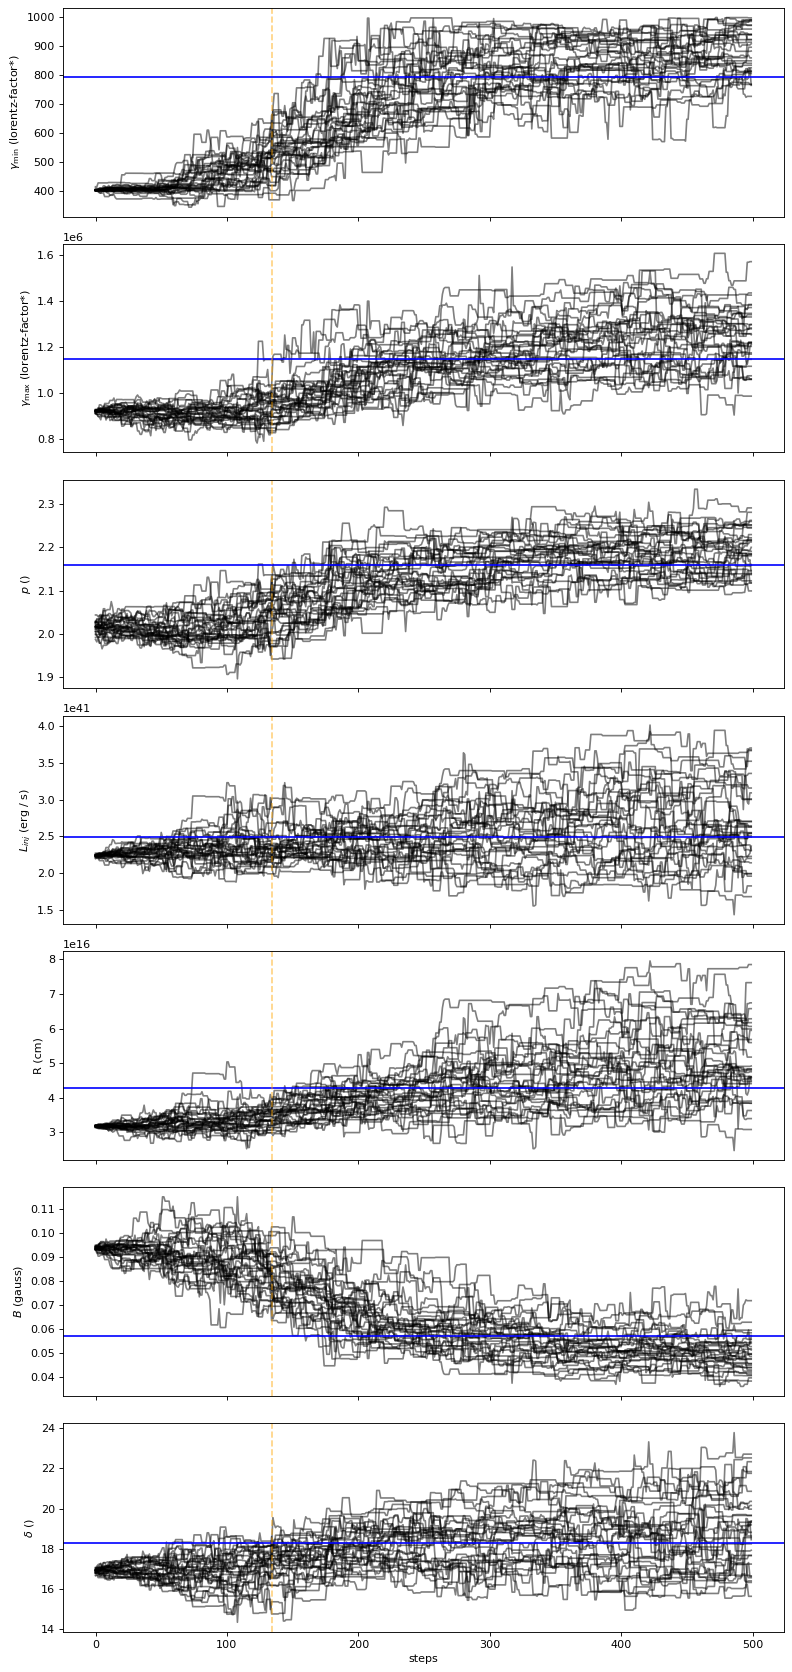

In [48]:
mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(log_plot=False)
plt.tight_layout()

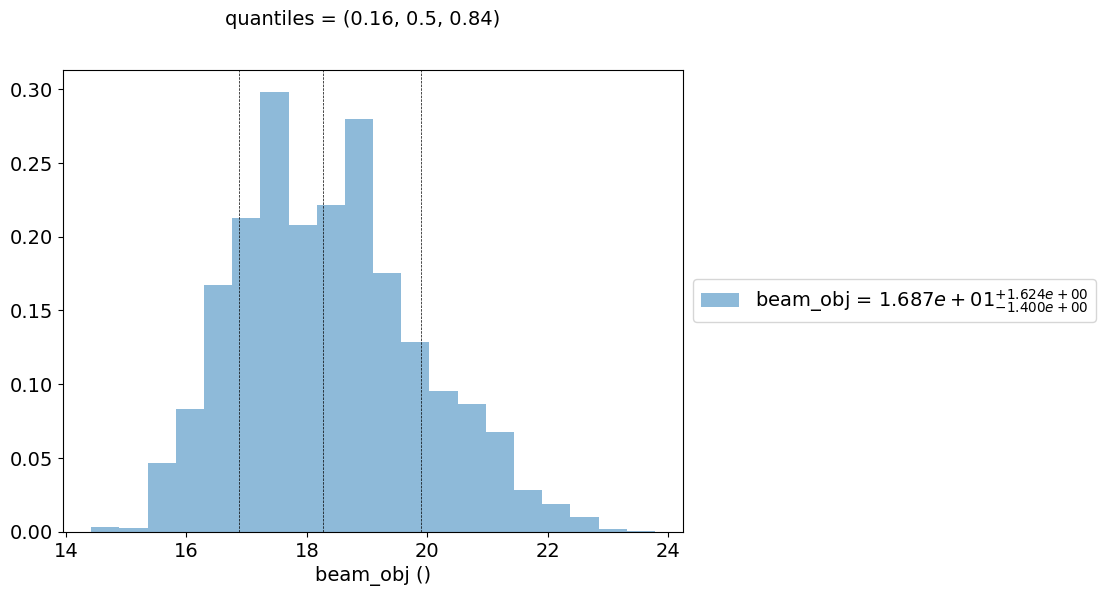

In [49]:

f=mcmc.plot_par('beam_obj',figsize=(8,6))
mpl.rcParams['figure.dpi'] = 80

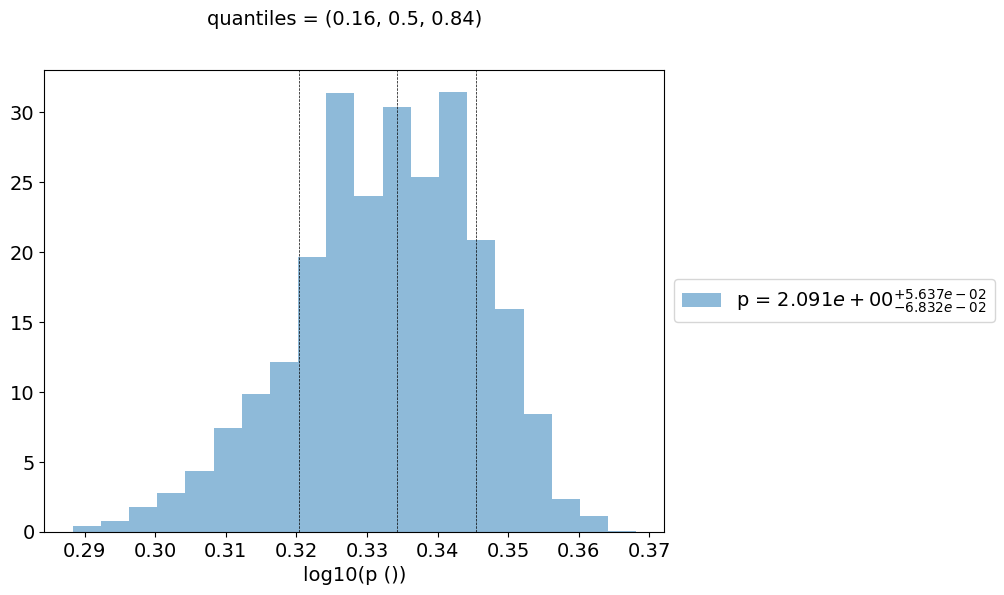

In [50]:
mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_par('p',log_plot=True,figsize=(8,6))

## Save and reuse MCMC

In [51]:
mcmc.save('mcmc_sampler.pkl')

In [52]:
from jetset.mcmc import McmcSampler
from jetset.data_loader import ObsData

sed_data=ObsData.load('Mrk_401.pkl')
ms=McmcSampler.load('mcmc_sampler.pkl')

import matplotlib as mpl


In [53]:
ms.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str11,str17,float64,bool,float64,float64,float64,float64,float64,float64,bool
leptonic_eq,gmin,9.586690e+02,False,9.586690e+02,6.245849e+02,7.943159e+02,9.216032e+02,1.000000e+01,1.000000e+03,False
leptonic_eq,gmax,1.214539e+06,False,1.214539e+06,1.010888e+06,1.144630e+06,1.301343e+06,1.000000e+05,5.000000e+06,False
leptonic_eq,p,2.243688e+00,False,2.243688e+00,2.090998e+00,2.159320e+00,2.215687e+00,-8.058281e+00,1.000000e+01,False
leptonic_eq,L_inj,2.278502e+41,False,2.278502e+41,2.148149e+41,2.491460e+41,3.006079e+41,1.000000e+38,1.000000e+43,False
leptonic_eq,R,4.733285e+16,False,4.733285e+16,3.576032e+16,4.280110e+16,5.445755e+16,3.162278e+15,1.906008e+17,False
leptonic_eq,B,4.448231e-02,False,4.448231e-02,4.799269e-02,5.728796e-02,7.145664e-02,0.000000e+00,5.629615e-01,False
leptonic_eq,beam_obj,2.068652e+01,False,2.068652e+01,1.687472e+01,1.827462e+01,1.989873e+01,5.000000e+00,5.000000e+01,False
leptonic_eq,T_esc_e_primaries,1.000000e+00,False,--,--,--,--,1.000000e+00,--,True
leptonic_eq,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


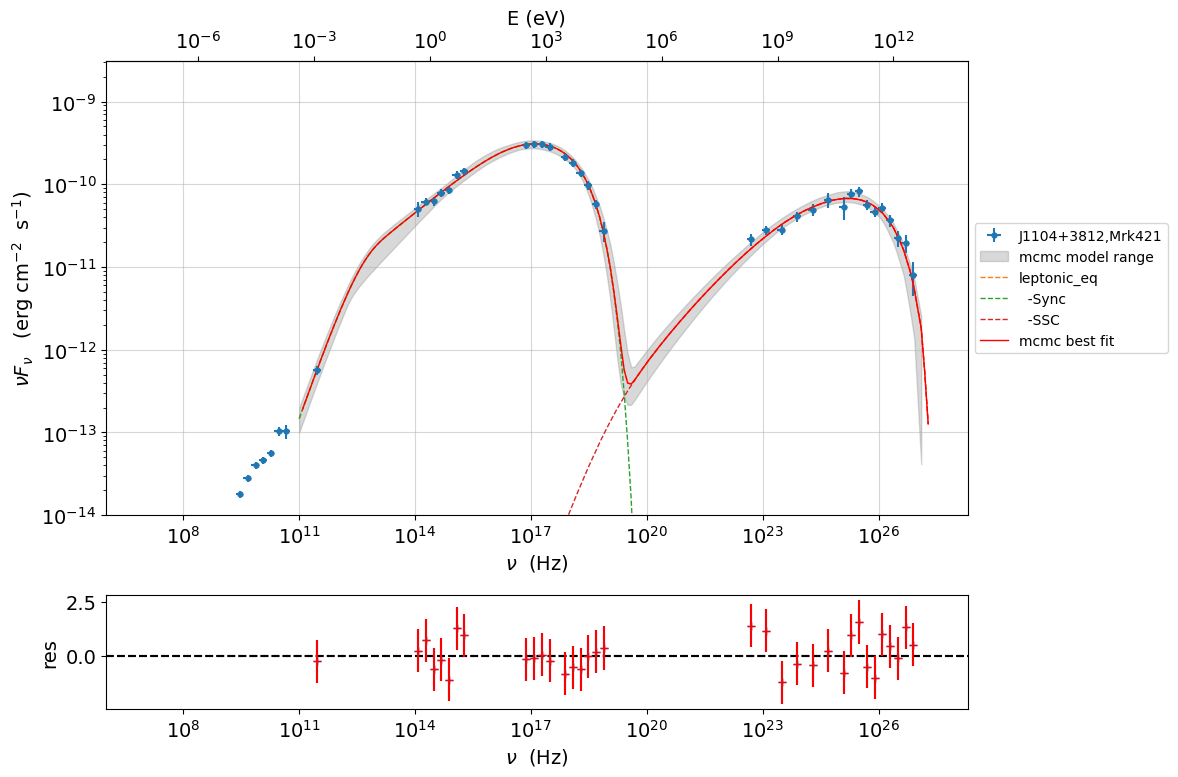

In [54]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=500,plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

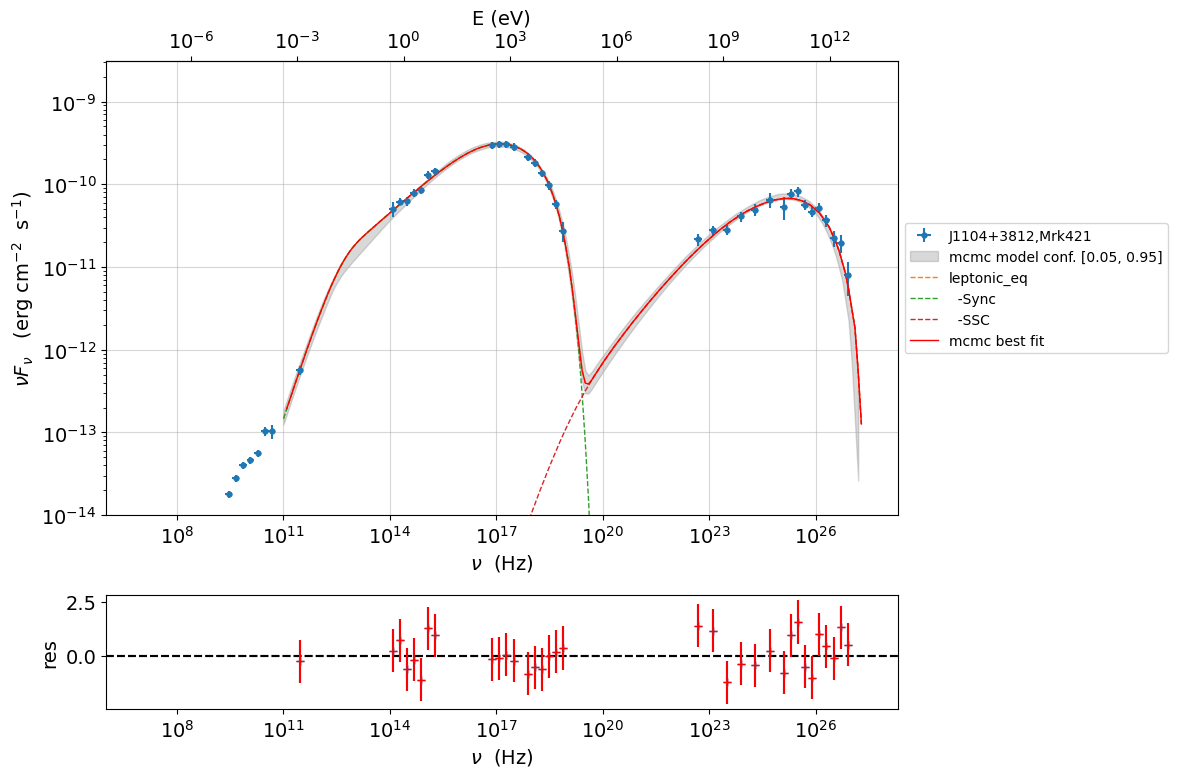

In [55]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95],plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

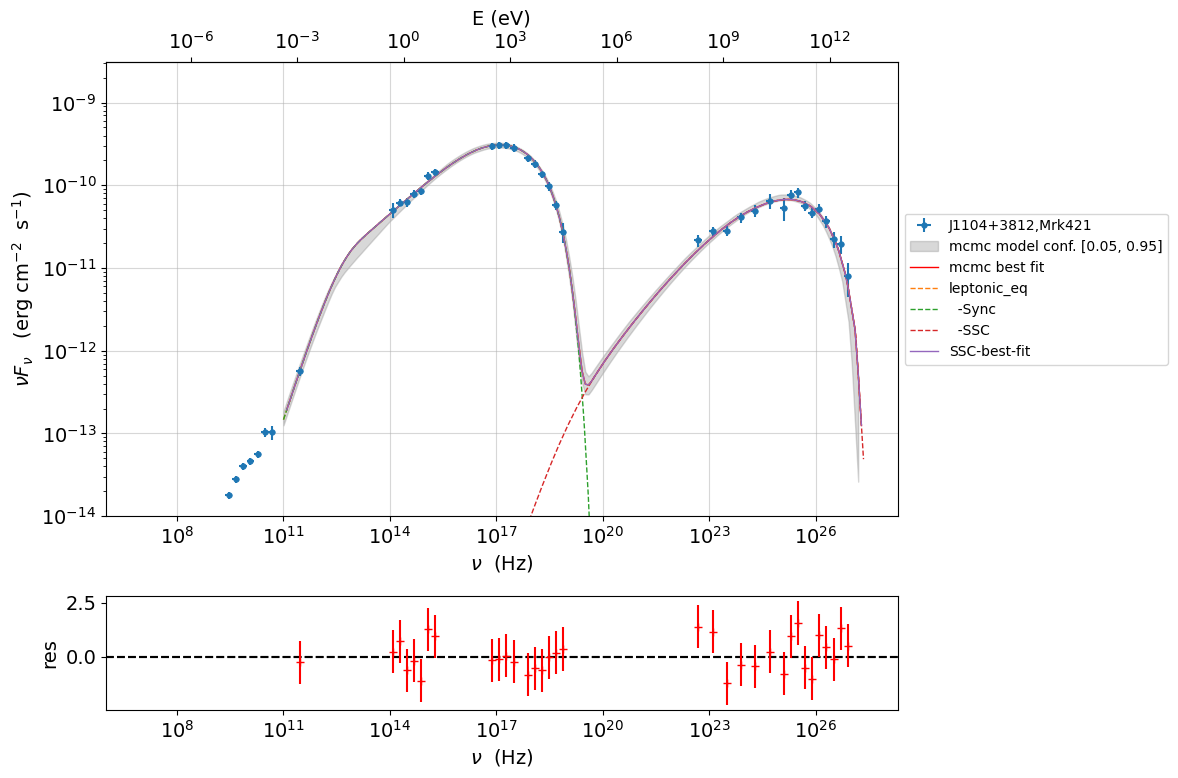

In [56]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95],plot_mcmc_best_fit_model=True)
p=ms.model.plot_model(plot_obj=p)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

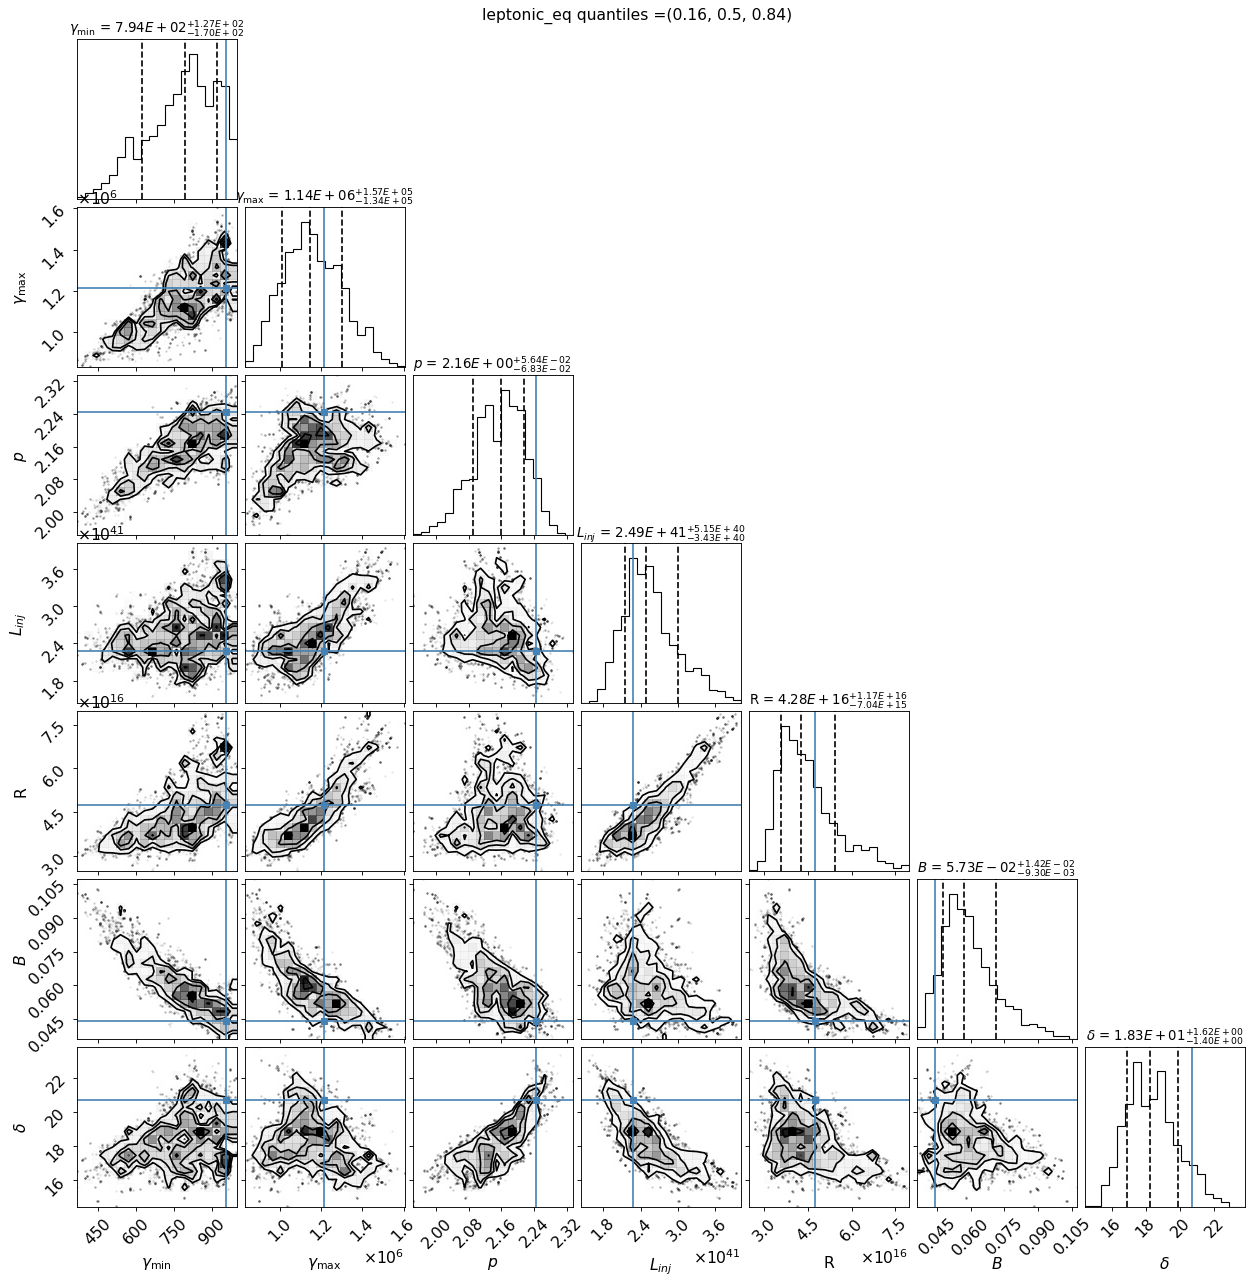

In [57]:
mpl.rcParams['figure.dpi'] = 80
f=ms.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

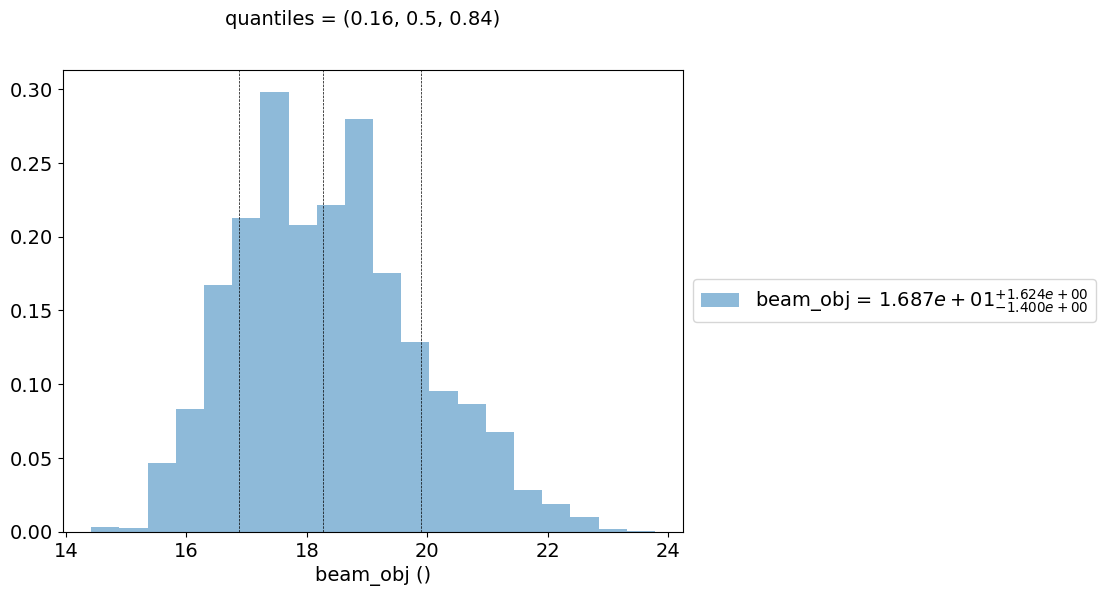

In [58]:
mpl.rcParams['figure.dpi'] = 80
f=ms.plot_par('beam_obj',log_plot=False,figsize=(8,6))

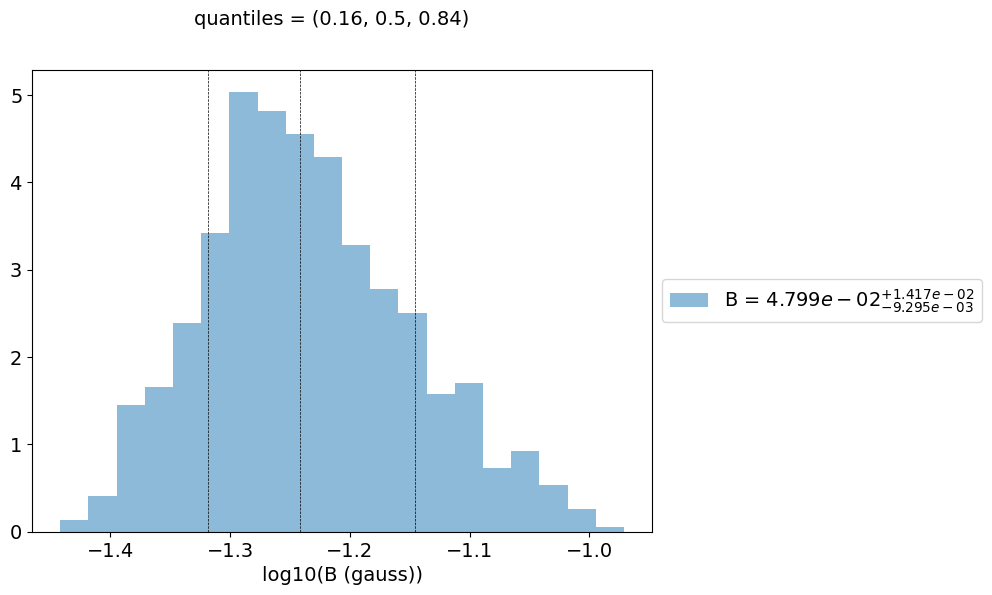

In [59]:
f=ms.plot_par('B',log_plot=True,figsize=(8,6))

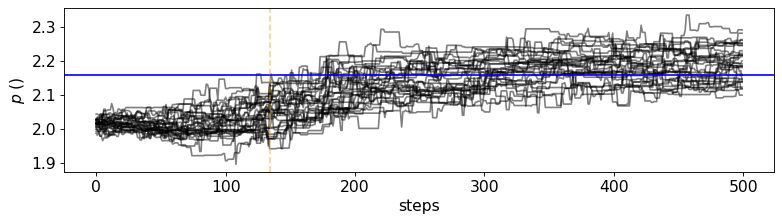

In [60]:
from matplotlib import pylab as plt
mpl.rcParams['figure.dpi'] = 80
f=ms.plot_chain(par_name='p',comp_name='leptonic_eq',log_plot=False)
plt.tight_layout()

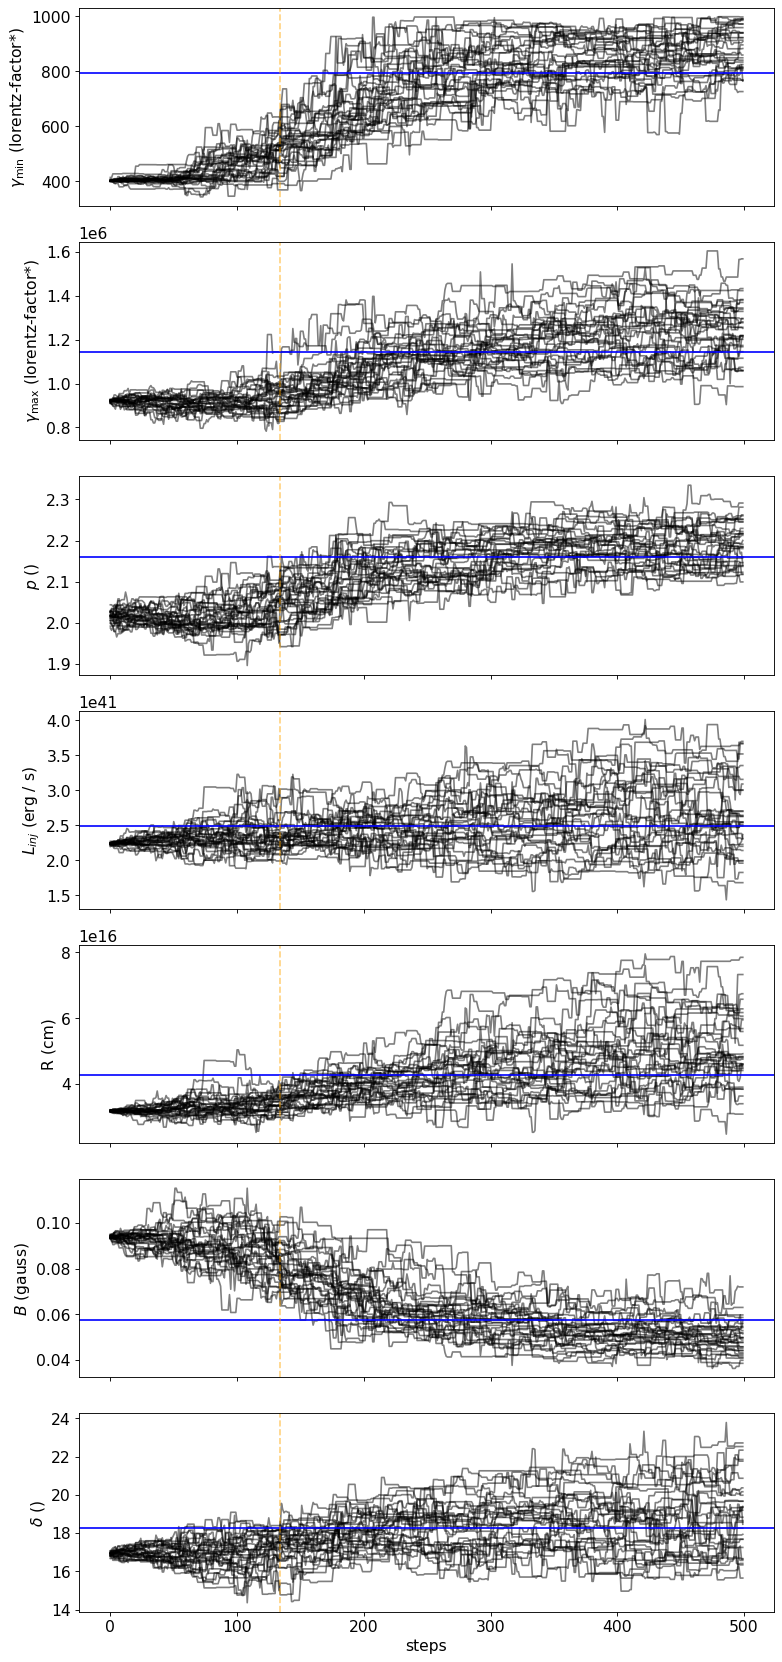

In [61]:
f=ms.plot_chain(log_plot=False)
plt.tight_layout()
mpl.rcParams['figure.dpi'] = 80